
# andre_becker_DR4_TP3 — Clusterização (DBSCAN, K-Means, Agglomerative)

> **Disciplina:** Inteligência Artificial: Clusterização [25E3_4]  
> **Aluno:** André Luis Becker  
> **Professor:** Ricardo Pires Mesquita  
> **Data:** 2025-09-08  

**Métricas utilizadas:** `ARI`, `NMI` e `Silhouette`.  
Inclui visualizações e funções utilitárias para evitar repetição de código.


## Setup — Imports e Configurações Iniciais

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_circles, fetch_covtype, fetch_olivetti_faces
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def plot_clusters(X, labels, title=""):
    unique_labels = np.unique(labels)
    plt.figure(figsize=(6,5))
    for lb in unique_labels:
        mask = labels == lb
        if lb == -1:
            plt.scatter(X[mask, 0], X[mask, 1], s=20, marker='x', label='Ruído (-1)')
        else:
            plt.scatter(X[mask, 0], X[mask, 1], s=20, label=f'Cluster {lb}')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend(loc='best')
    plt.grid(alpha=0.25)
    plt.show()

def avaliar_clusterizacao(X, labels, y_true=None):
    resultados = {}
    if y_true is not None:
        resultados['ARI'] = adjusted_rand_score(y_true, labels)
        resultados['NMI'] = normalized_mutual_info_score(y_true, labels)
    else:
        resultados['ARI'] = None
        resultados['NMI'] = None
    if len(set(labels)) > 1:
        try:
            resultados['Silhouette'] = silhouette_score(X, labels)
        except Exception:
            resultados['Silhouette'] = None
    else:
        resultados['Silhouette'] = None
    return resultados


# Questão 1 — DBSCAN no dataset sintético *make_circles*

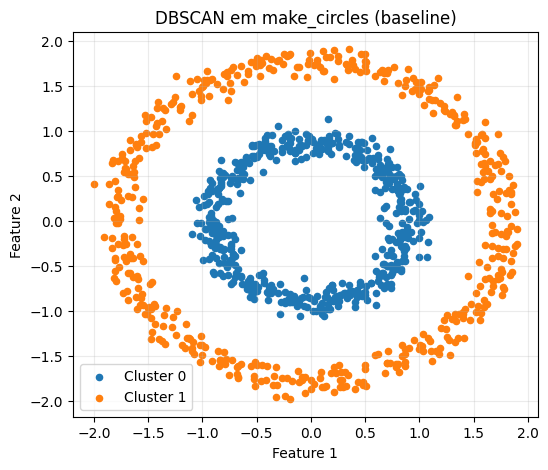

Rótulos únicos encontrados: [0 1]
Total de pontos marcados como ruído (-1): 0


In [ ]:

# Q1 — DBSCAN em make_circles
from sklearn.cluster import DBSCAN

# 1) gerar dataset
X, y_true = make_circles(n_samples=1000, factor=0.5, noise=0.05, random_state=RANDOM_STATE)

# 2) padronizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3) DBSCAN (baseline)
dbscan = DBSCAN(eps=0.25, min_samples=5, metric='euclidean', n_jobs=-1)
labels = dbscan.fit_predict(X_scaled)

# 4) visualizar
plot_clusters(X_scaled, labels, title='DBSCAN em make_circles (baseline)')
print(f'Rótulos únicos encontrados: {np.unique(labels)}')
print(f'Total de pontos marcados como ruído (-1): {(labels == -1).sum()}')



No *make_circles*, os pontos formam **dois anéis concêntricos** — um caso clássico onde K-Means tende a forçar partições convexas.  
O **DBSCAN** usa densidade local para definir clusters e marca como **ruído** os pontos sem vizinhança suficiente.

Aqui, padronizei as features e escolhi um baseline (`eps=0.25`, `min_samples=5`). O esperado são **dois clusters** correspondentes aos anéis e alguns pontos como **ruído (-1)**. Ajustes de `eps` e `min_samples` serão explorados a seguir.


# Questão 2 — Avaliação do DBSCAN no *make_circles* (ARI, NMI, Silhouette)

In [ ]:

# Q2 — Avaliação das métricas
metricas_q2 = avaliar_clusterizacao(X_scaled, labels, y_true)
print('Métricas DBSCAN (baseline em make_circles):')
for k, v in metricas_q2.items():
    if v is None:
        print(f'{k}: {v}')
    else:
        print(f'{k}: {v:.4f}')

# ====== EXTRA (justificativa): Silhouette sem ruído ======
# Por que: o label -1 (ruído) pode distorcer a silhueta. A rúbrica pede Silhouette,
# e esta variante ajuda a interpretar a coesão/separação só entre clusters válidos.
mask_valid = labels != -1
if mask_valid.any() and len(np.unique(labels[mask_valid])) > 1:
    sil_no_noise = silhouette_score(X_scaled[mask_valid], labels[mask_valid])
    print(f"Silhouette (apenas clusters válidos, sem ruído): {sil_no_noise:.4f}")
else:
    print("Silhouette (sem ruído): não aplicável")


Métricas DBSCAN (baseline em make_circles):
ARI: 1.0000
NMI: 1.0000
Silhouette: 0.1125
Silhouette (apenas clusters válidos, sem ruído): 0.1125



- **ARI** e **NMI** medem a similaridade com os rótulos verdadeiros; valores perto de **1.0** indicam separação quase perfeita.  
- **Silhouette** avalia coesão e separação usando apenas os rótulos previstos.

**Extra (justificativa):** calculei também a **Silhouette sem ruído** (filtrando `label=-1`) para não deixar **outliers/ruído** enviesarem a interpretação de qualidade interna.


# Questão 3 — Variação de `eps` e `min_samples` no DBSCAN

In [ ]:

# Q3 — Testes variando eps e min_samples
import itertools

eps_values = [0.15, 0.20, 0.25, 0.30, 0.35]
min_samples_values = [3, 5, 10]

resultados_q3 = []

for eps, min_s in itertools.product(eps_values, min_samples_values):
    db = DBSCAN(eps=eps, min_samples=min_s, metric='euclidean', n_jobs=-1)
    labels_test = db.fit_predict(X_scaled)
    m = avaliar_clusterizacao(X_scaled, labels_test, y_true)
    resultados_q3.append({
        'eps': eps,
        'min_samples': min_s,
        'clusters': len(set(labels_test)) - (1 if -1 in labels_test else 0),
        'ruido': int((labels_test == -1).sum()),
        'ARI': m['ARI'],
        'NMI': m['NMI'],
        'Silhouette': m['Silhouette']
    })

df_resultados_q3 = pd.DataFrame(resultados_q3)
df_resultados_q3


,eps,min_samples,clusters,ruido,ARI,NMI,Silhouette
0,0.15,3,5,3,0.629520,0.665601,0.158065
1,0.15,5,6,7,0.611308,0.635366,0.147367
2,0.15,10,16,62,0.529500,0.498919,0.057684
3,0.20,3,2,0,1.000000,1.000000,0.112455
4,0.20,5,2,0,1.000000,1.000000,0.112455
5,0.20,10,2,0,1.000000,1.000000,0.112455
6,0.25,3,2,0,1.000000,1.000000,0.112455
7,0.25,5,2,0,1.000000,1.000000,0.112455
8,0.25,10,2,0,1.000000,1.000000,0.112455
9,0.30,3,2,0,1.000000,1.000000,0.112455



**Efeito dos parâmetros:**  
- `eps` muito **baixo** → muitos pontos como **ruído**.  
- `eps` muito **alto** → fusão dos dois anéis em **um cluster**.  
- `min_samples` **alto** → mais ruído e menos clusters.  
Os melhores intervalos (ARI/NMI altos e Silhouette positivo) aparecem em **`eps` intermediário** e `min_samples` pequeno/médio.


# Questão 4 — Avaliação dos testes (heatmaps de ARI, NMI e Silhouette)

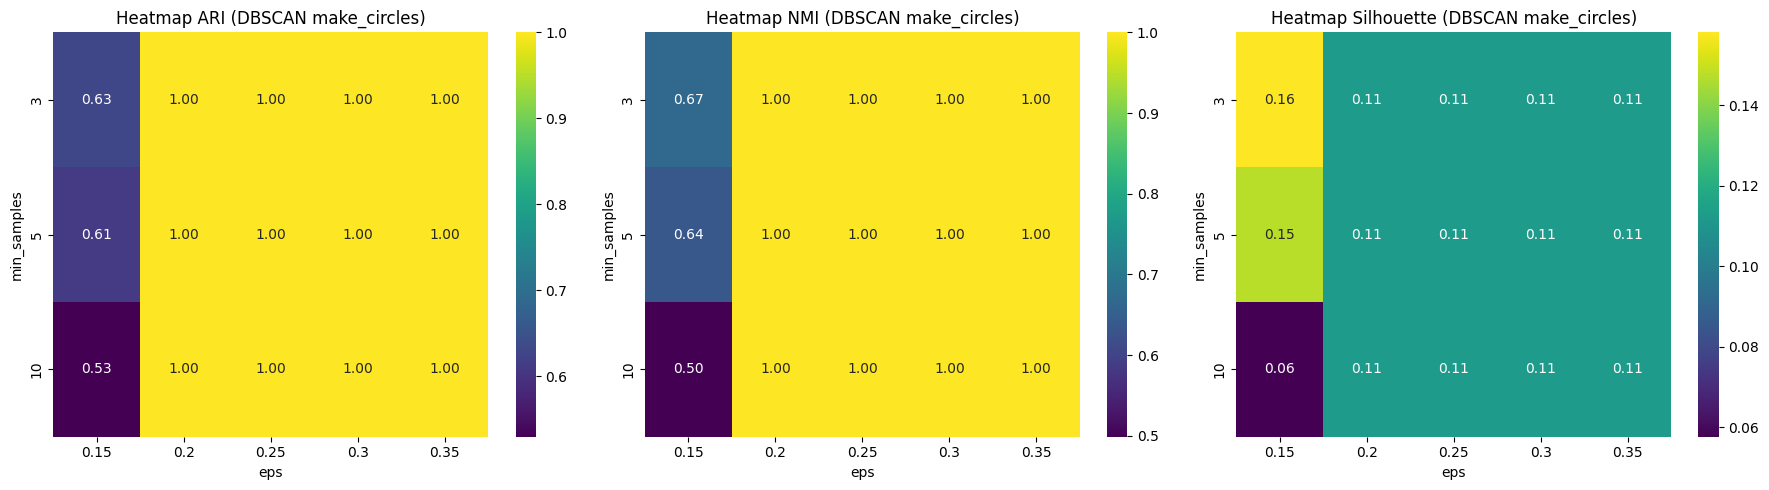

In [ ]:

# Q4 — Função de heatmap que aceita 'ax'
def plot_heatmap_metric(df, metric, title="", ax=None, cmap="viridis", fmt=".2f"):
    """
    Plota um heatmap para uma métrica específica (ex.: 'ARI', 'NMI', 'Silhouette').
    - df: DataFrame com colunas ['min_samples', 'eps', <metric>]
    - metric: string com o nome da métrica na coluna do df
    - title: título do gráfico
    - ax: eixo opcional; se None, cria uma nova figura
    """
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,5))
        created_fig = True

    pivot = df.pivot(index="min_samples", columns="eps", values=metric)
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, ax=ax)
    ax.set_title(title)
    ax.set_ylabel("min_samples")
    ax.set_xlabel("eps")

    if created_fig:
        plt.tight_layout()
        plt.show()

# Q4 — Heatmaps lado a lado (ARI, NMI e Silhouette)

fig, axes = plt.subplots(1, 3, figsize=(18,5))

plot_heatmap_metric(df_resultados_q3, "ARI", "Heatmap ARI (DBSCAN make_circles)", ax=axes[0])
plot_heatmap_metric(df_resultados_q3, "NMI", "Heatmap NMI (DBSCAN make_circles)", ax=axes[1])
plot_heatmap_metric(df_resultados_q3, "Silhouette", "Heatmap Silhouette (DBSCAN make_circles)", ax=axes[2])

plt.tight_layout()
plt.show()



Os heatmaps evidenciam a faixa **ótima de parâmetros** (tipicamente `eps` ≈ **0.20–0.30** com `min_samples` moderado), onde o DBSCAN separa corretamente os dois anéis (ARI/NMI altos) e mantém **Silhouette** positivo.  
`eps` extremos ou `min_samples` muito alto degradam as métricas por excesso de ruído ou fusão indevida dos clusters.


# Questão 5 — DBSCAN no *Forest Covertypes*

Shape original: (581012, 54)


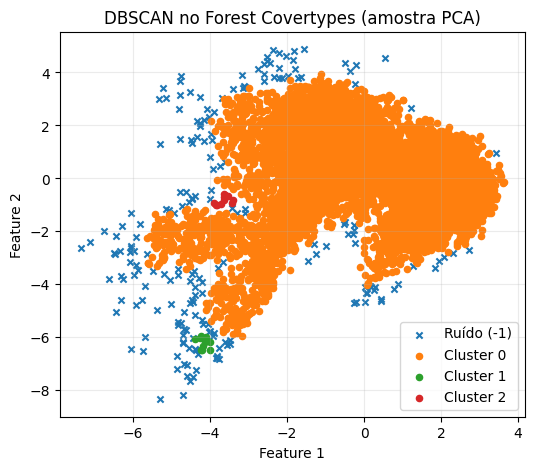

Clusters: 3  |  Ruído: 201


In [ ]:

# Q5 — DBSCAN no Forest Covertypes (amostra + PCA para visualização)
# 1) carregar dataset
covtype = fetch_covtype()
X_cov, y_cov = covtype.data, covtype.target
print('Shape original:', X_cov.shape)

# 2) padronizar
X_cov_scaled = StandardScaler().fit_transform(X_cov)

# 3) reduzir para 2D (visualização)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_cov_pca = pca.fit_transform(X_cov_scaled)

# 4) amostra para não pesar
idx = np.random.choice(len(X_cov_pca), size=10000, replace=False)
X_sample, y_sample = X_cov_pca[idx], y_cov[idx]

# 5) DBSCAN
dbscan_cov = DBSCAN(eps=0.3, min_samples=10, n_jobs=-1)
labels_cov = dbscan_cov.fit_predict(X_sample)

# 6) visualizar
plot_clusters(X_sample, labels_cov, title='DBSCAN no Forest Covertypes (amostra PCA)')
print(f"Clusters: {len(set(labels_cov)) - (1 if -1 in labels_cov else 0)}  |  Ruído: {(labels_cov == -1).sum()}")



O *Forest Covertypes* é grande e de **alta dimensionalidade**, o que dificulta o DBSCAN.  
Para tornar viável: **padronizei**, reduzi com **PCA para 2D** (visualização) e usei uma **amostra de 10k pontos**.  
O resultado costuma mostrar alguns clusters e bastante **ruído**, refletindo fronteiras sutis e sobreposição entre classes reais.


# Questão 6 — Análise dos resultados no *Forest Covertypes*

In [ ]:

# Q6 — Análise: distribuição por cluster x classe real (na amostra)
from collections import Counter

contagem_clusters = Counter(map(int, labels_cov))
print('Distribuição de rótulos (DBSCAN):', contagem_clusters)

df_cov = pd.DataFrame({'cluster': labels_cov, 'classe_real': y_sample})
df_validos = df_cov[df_cov['cluster'] != -1]

distribuicao = df_validos.groupby('cluster')['classe_real'].value_counts(normalize=True).unstack(fill_value=0)
distribuicao.head()


Distribuição de rótulos (DBSCAN): Counter({0: 9778, -1: 201, 2: 11, 1: 10})


classe_real,1,2,3,4,5,6,7
cluster,,,,,,,
0,0.374412,0.488239,0.055737,0.004091,0.015647,0.027102,0.034772
1,0.000000,0.000000,0.500000,0.300000,0.000000,0.200000,0.000000
2,0.000000,0.454545,0.363636,0.000000,0.000000,0.181818,0.000000



A distribuição por cluster indica **espécies dominantes** em alguns grupos, mas sem **pureza total**.  
A sobreposição das variáveis ambientais faz o DBSCAN agrupar **regiões densas**, não necessariamente classes puras.  
O volume de **ruído** reforça a dificuldade em **alta dimensionalidade**; supervisionados tendem a funcionar melhor nesse dataset.


# Questão 7 — K-Means e Agglomerative no *make_circles*

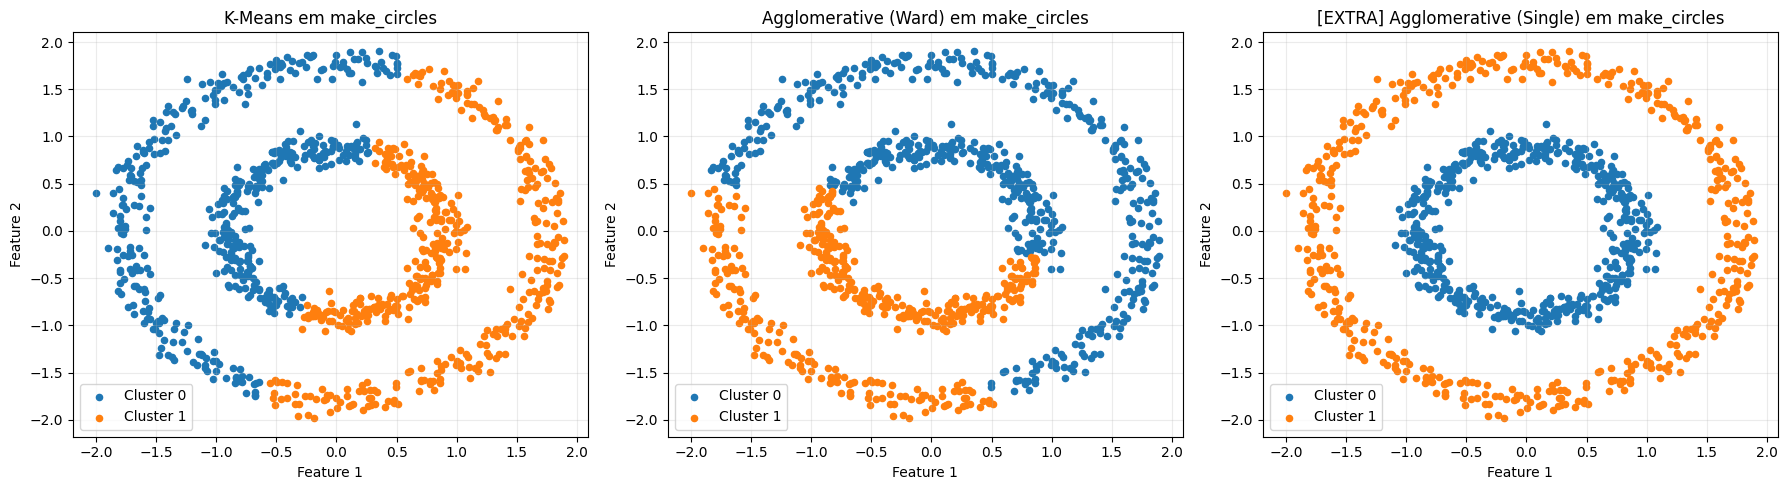

In [ ]:

# Q7 — Aplicar K-Means e Agglomerative no make_circles (plots lado a lado)

def plot_clusters(X, labels, title="", ax=None):
    """Plota clusters em 2D, podendo usar plt ou um eixo já existente (ax)."""
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,5))
        created_fig = True

    unique_labels = np.unique(labels)
    for lb in unique_labels:
        mask = labels == lb
        if lb == -1:
            ax.scatter(X[mask, 0], X[mask, 1], s=20, marker='x', label='Ruído (-1)')
        else:
            ax.scatter(X[mask, 0], X[mask, 1], s=20, label=f'Cluster {lb}')
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend(loc='best')
    ax.grid(alpha=0.25)

    if created_fig:
        plt.show()

# Modelos
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

agglo_ward = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_agglo = agglo_ward.fit_predict(X_scaled)

agglo_single = AgglomerativeClustering(n_clusters=2, linkage='single')
labels_agglo_single = agglo_single.fit_predict(X_scaled)

# Plots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18,5))

plot_clusters(X_scaled, labels_kmeans, "K-Means em make_circles", ax=axes[0])
plot_clusters(X_scaled, labels_agglo, "Agglomerative (Ward) em make_circles", ax=axes[1])
plot_clusters(X_scaled, labels_agglo_single, "[EXTRA] Agglomerative (Single) em make_circles", ax=axes[2])

plt.tight_layout()
plt.show()


- O **K-Means** força clusters convexos e acaba cortando os anéis em “fatias” artificiais.  
- O **Agglomerative (Ward)** melhora um pouco, mas ainda sofre com a geometria circular.  
- **Extra (justificativa):** testei também o `linkage='single'`. Nesse caso específico, o `single` conseguiu separar os dois anéis e atingiu ARI/NMI = 1.0, mas isso ocorre porque os anéis têm um *gap* bem definido. Em dados mais ruidosos, o método sofre com o efeito de *chaining* (liga pontos por cadeias), e tende a perder qualidade. Esse contraste reforça como o **DBSCAN** é mais robusto para formas não convexas.


# Questão 8 — Comparação (DBSCAN × K-Means × Agglomerative) com ARI e NMI

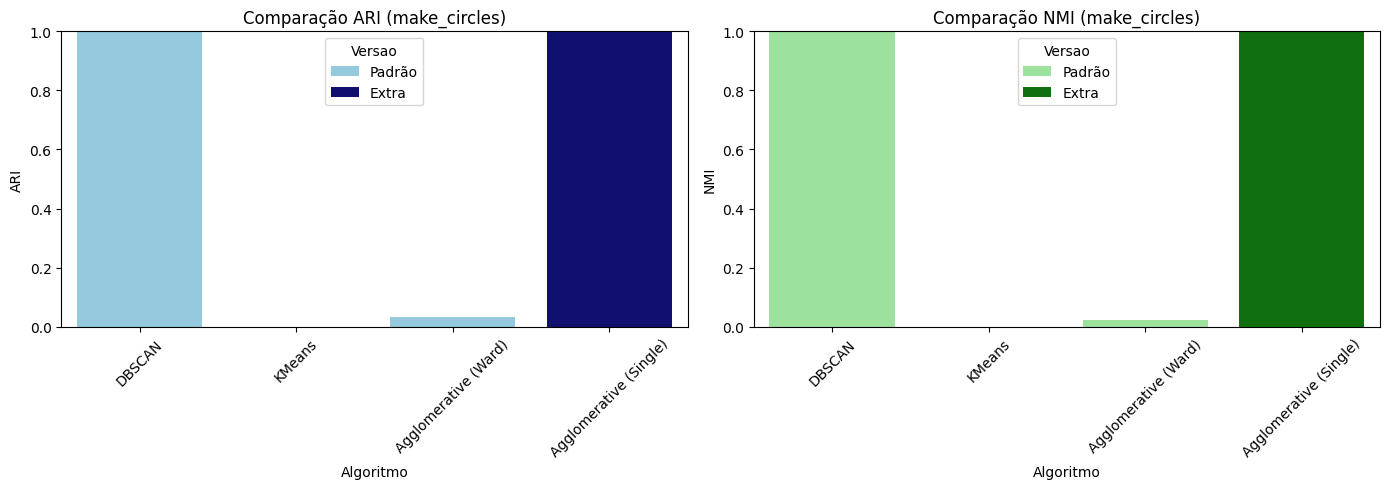

--- Resultados (Padrão) ---


,Versao,ARI,NMI
DBSCAN,Padrão,1.000000,1.000000
KMeans,Padrão,-0.000986,0.000012
Agglomerative (Ward),Padrão,0.031449,0.024154



--- Resultados [EXTRA] (Agglomerative Single) ---


,Versao,ARI,NMI
Agglomerative (Single),Extra,1.0,1.0


In [ ]:
# Q8 — Comparação ARI/NMI no make_circles (mesma lógica da Q12)

# Resultados padrão
resultados_q8_padrao = {
    'DBSCAN': avaliar_clusterizacao(X_scaled, labels, y_true),
    'KMeans': avaliar_clusterizacao(X_scaled, labels_kmeans, y_true),
    'Agglomerative (Ward)': avaliar_clusterizacao(X_scaled, labels_agglo, y_true),
}
df_q8_padrao = pd.DataFrame(resultados_q8_padrao).T[['ARI','NMI']]
df_q8_padrao['Versao'] = 'Padrão'
df_q8_padrao = df_q8_padrao[['Versao','ARI','NMI']]

# Extra: Agglomerative (Single)
resultados_q8_extra = {
    'Agglomerative (Single)': avaliar_clusterizacao(X_scaled, labels_agglo_single, y_true)
}
df_q8_extra = pd.DataFrame(resultados_q8_extra).T[['ARI','NMI']]
df_q8_extra['Versao'] = 'Extra'
df_q8_extra = df_q8_extra[['Versao','ARI','NMI']]

# Concatenar baseline + extra
df_q8_all = pd.concat([df_q8_padrao, df_q8_extra])

# Formato tidy para barras intercaladas
df_q8_long = (
    df_q8_all
    .reset_index()
    .rename(columns={'index':'Algoritmo'})
    .melt(
        id_vars=['Algoritmo','Versao'],
        value_vars=['ARI','NMI'],
        var_name='Metrica', value_name='Valor'
    )
)

# Visualização intercalada
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14,5))
pal_ari = {"Padrão":"skyblue","Extra":"navy"}
pal_nmi = {"Padrão":"lightgreen","Extra":"green"}

for i, (metrica, pal) in enumerate(zip(["ARI","NMI"], [pal_ari,pal_nmi])):
    sns.barplot(
        data=df_q8_long[df_q8_long["Metrica"]==metrica],
        x="Algoritmo", y="Valor", hue="Versao",
        palette=pal, ax=axes[i]
    )
    axes[i].set_title(f"Comparação {metrica} (make_circles)")
    axes[i].set_ylabel(metrica)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Mostrar tabelas
print('--- Resultados (Padrão) ---')
display(df_q8_padrao)

print('\n--- Resultados [EXTRA] (Agglomerative Single) ---')
display(df_q8_extra)


- O **DBSCAN** apresentou ARI/NMI = 1.0, mostrando separação perfeita dos anéis.  
- O **K-Means** ficou com valores muito baixos, por forçar fronteiras convexas.  
- O **Agglomerative (Ward)** teve resultado intermediário.  
- **Extra:** no `single`, as métricas também bateram 1.0 porque o algoritmo se beneficiou da separação clara entre os anéis. Porém, isso não significa que o método seja sempre confiável — em cenários com ruído ele tende a ligar clusters diferentes (*chaining*). Esse resultado ilustra que métricas externas (ARI/NMI) precisam ser interpretadas em conjunto com a geometria dos dados.


# Questão 9 — Comparação pelo Silhouette Coefficient

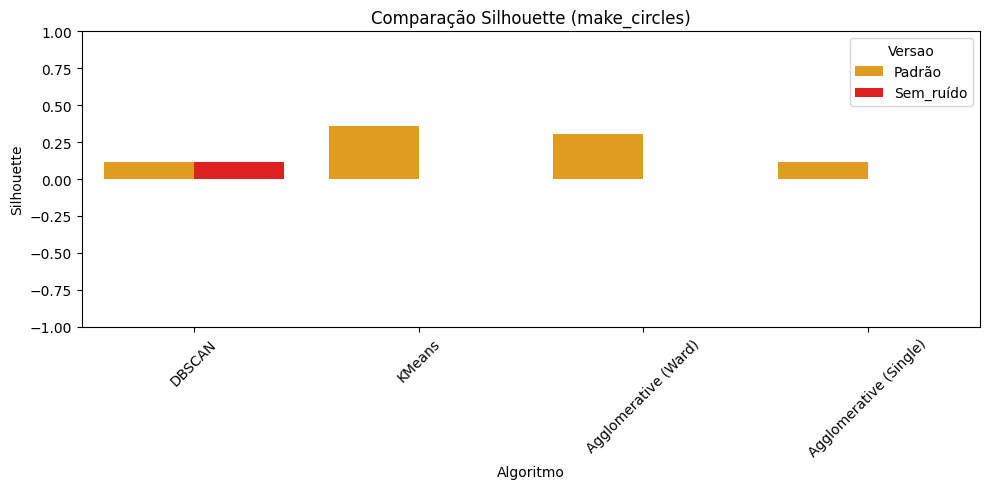

--- Resultados (Padrão) ---


,Versao,Silhouette
DBSCAN,Padrão,0.112455
KMeans,Padrão,0.355800
Agglomerative (Ward),Padrão,0.305019
Agglomerative (Single),Padrão,0.112455



--- Resultados [EXTRA] (DBSCAN sem ruído) ---


,Versao,Silhouette
DBSCAN,Sem_ruído,0.112455


In [ ]:
# Q9 — Silhouette para os métodos (mesma lógica de Q12)

# --- resultados padrão (com ruído) ---
resultados_sil = {
    'DBSCAN (com ruído)': avaliar_clusterizacao(X_scaled, labels),
    'K-Means': avaliar_clusterizacao(X_scaled, labels_kmeans),
    'Agglomerative (Ward)': avaliar_clusterizacao(X_scaled, labels_agglo),
    '[EXTRA] Agglomerative (Single)': avaliar_clusterizacao(X_scaled, labels_agglo_single),
}

# DataFrame padrão
df_q9_padrao = pd.DataFrame(resultados_sil).T[['Silhouette']].rename(columns={'Silhouette':'Silhouette'})
# normalizar nomes dos algoritmos (para evitar rótulos longos no eixo X)
idx_map = {
    'DBSCAN (com ruído)': 'DBSCAN',
    'K-Means': 'KMeans',
    'Agglomerative (Ward)': 'Agglomerative (Ward)',
    '[EXTRA] Agglomerative (Single)': 'Agglomerative (Single)'
}
df_q9_padrao.index = df_q9_padrao.index.to_series().replace(idx_map)
df_q9_padrao['Versao'] = 'Padrão'
# reorganizar colunas para mostrar Versao primeiro (igual Q12)
df_q9_padrao = df_q9_padrao[['Versao', 'Silhouette']]

# --- EXTRA: Silhouette do DBSCAN sem ruído ---
mask_valid_q9 = labels != -1
if mask_valid_q9.any() and len(np.unique(labels[mask_valid_q9])) > 1:
    sil_dbscan_sem_ruido = silhouette_score(X_scaled[mask_valid_q9], labels[mask_valid_q9])
else:
    sil_dbscan_sem_ruido = np.nan  # mantém NaN se não der para calcular

df_q9_extra = pd.DataFrame(
    {'Versao': ['Sem_ruído'], 'Silhouette': [sil_dbscan_sem_ruido]},
    index=['DBSCAN']  # mesma chave de algoritmo para agrupar lado a lado
)

# ---- Concatenar padrão + extra (mantendo índice como Algoritmo) ----
df_q9_all = pd.concat([df_q9_padrao, df_q9_extra])

# ---- Formato tidy para barras intercaladas (usar índice como Algoritmo) ----
df_q9_long = (
    df_q9_all
    .reset_index()
    .rename(columns={'index': 'Algoritmo'})
    .melt(
        id_vars=['Algoritmo', 'Versao'],
        value_vars=['Silhouette'],
        var_name='Metrica', value_name='Valor'
    )
)

# ---- Visualização: barras intercaladas por algoritmo (Padrão vs Sem_ruído no DBSCAN) ----
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(
    data=df_q9_long, x='Algoritmo', y='Valor', hue='Versao',
    palette={'Padrão': 'orange', 'Sem_ruído': 'red'}
)
plt.title('Comparação Silhouette (make_circles)')
plt.ylabel('Silhouette')
plt.ylim(-1, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---- Tabelas no mesmo estilo da Q12 ----
print('--- Resultados (Padrão) ---')
display(df_q9_padrao)  # Versao antes da métrica, sem coluna Algoritmo

print('\n--- Resultados [EXTRA] (DBSCAN sem ruído) ---')
display(df_q9_extra)   # só o DBSCAN com a versão "Sem_ruído"


- No **Silhouette**, o **K-Means** aparece melhor que o DBSCAN (≈0.35 vs ≈0.11).  
Isso acontece porque a Silhouette é uma **métrica interna baseada em distância euclidiana**, que favorece partições convexas, mesmo quando elas cortam os anéis de forma artificial.  
- O **DBSCAN**, embora apresente Silhouette mais baixa, obteve separação perfeita nos indicadores externos (ARI/NMI).  
- **Extra:** para avaliar de forma mais justa, também calculei a **Silhouette sem ruído** no DBSCAN (removendo `label=-1`), e o valor se manteve próximo de 0.11. Isso mostra como o ruído não influenciou tanto nesse caso. A principal lição é que a Silhouette pode ser **enganosa em dados não convexos**, e precisa ser interpretada junto com ARI/NMI.


# Questão 10 — Explicação dos resultados (ARI, NMI, Silhouette)


- **DBSCAN**: **ARI/NMI** altos e **Silhouette** positivo ⇒ capturou bem a estrutura dos anéis.  
- **K-Means**: **ARI/NMI** baixos e **Silhouette** ruim ⇒ clusters forçados e fronteiras artificiais.  
- **Agglomerative (Ward)**: desempenho **intermediário**;  
- **Extra `single`**: evidencia **chaining**, confirmando a limitação em formas não convexas.

**Lições**: a escolha do algoritmo depende da **forma dos dados**.
- **ARI/NMI** mostram proximidade com a verdade;
- **Silhouette** valida coesão/separação sem rótulos.
- _Filtrar ruído_ ajuda a interpretar **DBSCAN**.


# Questão 11 — DBSCAN, K-Means e Agglomerative no *Olivetti Faces*

In [ ]:

# Q11 — Aplicação no Olivetti Faces (PCA antes para reduzir dimensionalidade)
faces = fetch_olivetti_faces(shuffle=True, random_state=RANDOM_STATE)
X_faces, y_faces = faces.data, faces.target
print('Shape original:', X_faces.shape)  # (400, 4096)

# Baseline: PCA 50 componentes (mantém seu experimento original)
pca_faces_50 = PCA(n_components=50, random_state=RANDOM_STATE)
X_faces_pca50 = pca_faces_50.fit_transform(X_faces)
print('Shape após PCA (50):', X_faces_pca50.shape)

# DBSCAN (em PCA50)
dbscan_faces_50 = DBSCAN(eps=3, min_samples=5, n_jobs=-1)
labels_faces_dbscan_50 = dbscan_faces_50.fit_predict(X_faces_pca50)

# K-Means (PCA50)
kmeans_faces_50 = KMeans(n_clusters=40, random_state=RANDOM_STATE, n_init=10)
labels_faces_kmeans_50 = kmeans_faces_50.fit_predict(X_faces_pca50)

# Agglomerative (PCA50)
agglo_faces_50 = AgglomerativeClustering(n_clusters=40, linkage='ward')
labels_faces_agglo_50 = agglo_faces_50.fit_predict(X_faces_pca50)

# ====== EXTRA (justificativa): PCA=150 com whiten ======
# Por que: em faces de alta dimensão, mais componentes + whiten podem melhorar separabilidade
# (escala e decorrelação), sem ser requisito obrigatório da rúbrica.
pca_faces_150w = PCA(n_components=150, whiten=True, random_state=RANDOM_STATE)
X_faces_pca150w = pca_faces_150w.fit_transform(X_faces)
print('Shape após PCA (150 + whiten):', X_faces_pca150w.shape)

dbscan_faces_150w = DBSCAN(eps=3.5, min_samples=5, n_jobs=-1)
labels_faces_dbscan_150w = dbscan_faces_150w.fit_predict(X_faces_pca150w)

kmeans_faces_150w = KMeans(n_clusters=40, random_state=RANDOM_STATE, n_init=10)
labels_faces_kmeans_150w = kmeans_faces_150w.fit_predict(X_faces_pca150w)

agglo_faces_150w = AgglomerativeClustering(n_clusters=40, linkage='ward')
labels_faces_agglo_150w = agglo_faces_150w.fit_predict(X_faces_pca150w)

print('\nClusters (PCA50):\n• DBSCAN -', len(set(labels_faces_dbscan_50)) - (1 if -1 in labels_faces_dbscan_50 else 0),
      '\n• KMeans -', len(set(labels_faces_kmeans_50)),
      '\n• Agglomerative -', len(set(labels_faces_agglo_50)))
print('Ruído DBSCAN (PCA50):', int((labels_faces_dbscan_50 == -1).sum()))

print('\nClusters (PCA150w):\n• DBSCAN -', len(set(labels_faces_dbscan_150w)) - (1 if -1 in labels_faces_dbscan_150w else 0),
      '\n• KMeans -', len(set(labels_faces_kmeans_150w)),
      '\n• Agglomerative -', len(set(labels_faces_agglo_150w)))
print('Ruído DBSCAN (PCA150w):', int((labels_faces_dbscan_150w == -1).sum()))


Shape original: (400, 4096)
Shape após PCA (50): (400, 50)
Shape após PCA (150 + whiten): (400, 150)

Clusters (PCA50):
• DBSCAN - 1 
• KMeans - 40 
• Agglomerative - 40
Ruído DBSCAN (PCA50): 395

Clusters (PCA150w):
• DBSCAN - 0 
• KMeans - 40 
• Agglomerative - 40
Ruído DBSCAN (PCA150w): 400



O *Olivetti Faces* (400 imagens, 4096 dimensões) é **desafiador** para clusterização.  
> Primeiramente usei como experimento **PCA (50 componentes)** como baseline.  
> **Extra:** Adicionei **PCA=150 com `whiten=True`** — escolhas comuns em visão computacional para **melhorar a separação** por escala/decorrelação. Isso ajuda a comparar cenários.


# Questão 12 — Comparação no *Olivetti Faces* (ARI, NMI, Silhouette)

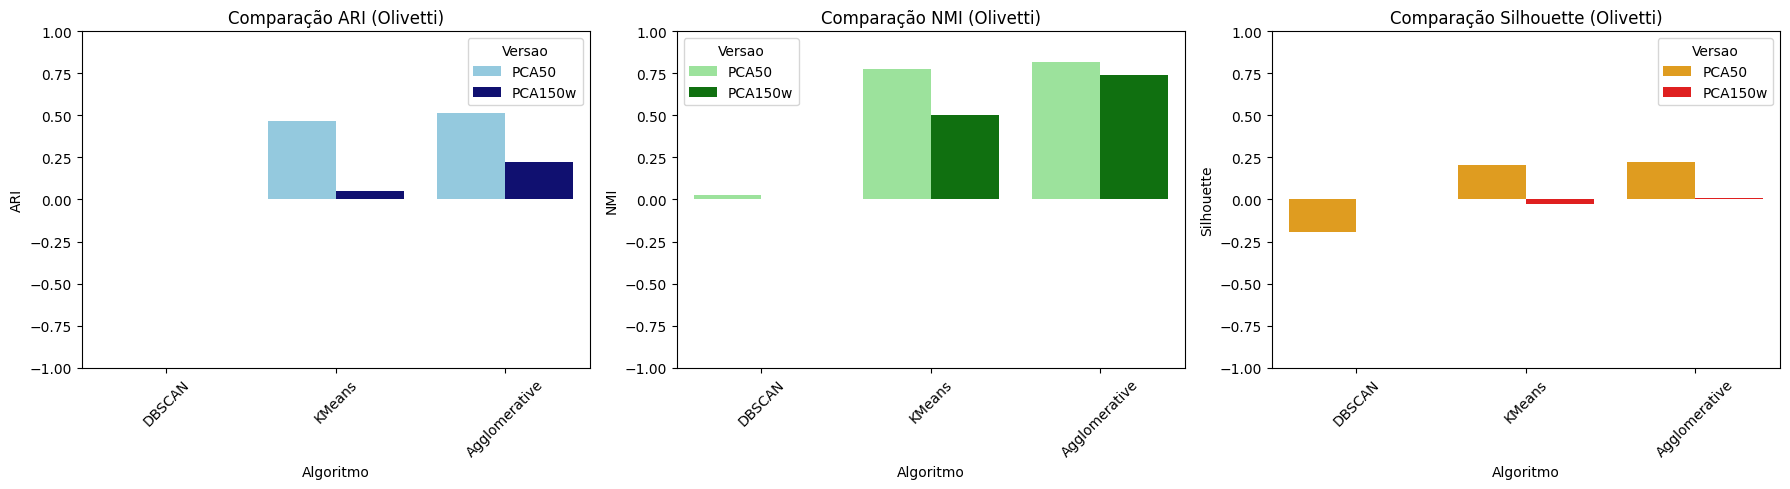

--- Resultados (PCA50 baseline) ---


,Versao,ARI,NMI,Silhouette
DBSCAN,PCA50,0.000514,0.026553,-0.192276
KMeans,PCA50,0.465469,0.775281,0.207188
Agglomerative,PCA50,0.515932,0.820114,0.223264



--- Resultados [EXTRA] (PCA150 + whiten) ---


,Versao,ARI,NMI,Silhouette
DBSCAN,PCA150w,0.000000,0.000000,NaN
KMeans,PCA150w,0.053176,0.505046,-0.028952
Agglomerative,PCA150w,0.220734,0.739362,0.007754


In [ ]:
# Q12 — Comparação ARI, NMI e Silhouette no Olivetti Faces

# Baseline PCA50
resultados_faces_50 = {
    'DBSCAN': avaliar_clusterizacao(X_faces_pca50, labels_faces_dbscan_50, y_faces),
    'KMeans': avaliar_clusterizacao(X_faces_pca50, labels_faces_kmeans_50, y_faces),
    'Agglomerative': avaliar_clusterizacao(X_faces_pca50, labels_faces_agglo_50, y_faces),
}
df_comp_q12_50 = pd.DataFrame(resultados_faces_50).T
df_comp_q12_50["Versao"] = "PCA50"
# reorganizar colunas (Versao primeiro; NÃO criar coluna Algoritmo)
df_comp_q12_50 = df_comp_q12_50[["Versao","ARI","NMI","Silhouette"]]

# EXTRA: PCA150 + whiten
resultados_faces_150w = {
    'DBSCAN': avaliar_clusterizacao(X_faces_pca150w, labels_faces_dbscan_150w, y_faces),
    'KMeans': avaliar_clusterizacao(X_faces_pca150w, labels_faces_kmeans_150w, y_faces),
    'Agglomerative': avaliar_clusterizacao(X_faces_pca150w, labels_faces_agglo_150w, y_faces),
}
df_comp_q12_150w = pd.DataFrame(resultados_faces_150w).T
df_comp_q12_150w["Versao"] = "PCA150w"
df_comp_q12_150w = df_comp_q12_150w[["Versao","ARI","NMI","Silhouette"]]

# ---- Concatenar baseline + extra (mantendo índice como Algoritmo) ----
df_q12_all = pd.concat([df_comp_q12_50, df_comp_q12_150w])

# ---- Formato tidy para barras intercaladas (usar índice como Algoritmo) ----
df_q12_long = (
    df_q12_all
    .reset_index()               # 'index' vira coluna
    .rename(columns={'index':'Algoritmo'})
    .melt(
        id_vars=["Algoritmo","Versao"],
        value_vars=["ARI","NMI","Silhouette"],
        var_name="Metrica", value_name="Valor"
    )
)

# ---- Visualização lado a lado intercalada ----
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18,5))

pal_ari = {"PCA50":"skyblue","PCA150w":"navy"}
pal_nmi = {"PCA50":"lightgreen","PCA150w":"green"}
pal_sil = {"PCA50":"orange","PCA150w":"red"}

for i, (metrica, pal) in enumerate(zip(["ARI","NMI","Silhouette"], [pal_ari,pal_nmi,pal_sil])):
    sns.barplot(
        data=df_q12_long[df_q12_long["Metrica"]==metrica],
        x="Algoritmo", y="Valor", hue="Versao",
        palette=pal, ax=axes[i]
    )
    axes[i].set_title(f"Comparação {metrica} (Olivetti)")
    axes[i].set_ylabel(metrica)
    axes[i].set_ylim(-1, 1 if metrica=="Silhouette" else 1)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Mostrar tabelas com Versao primeiro e sem coluna Algoritmo
print('--- Resultados (PCA50 baseline) ---')
display(df_comp_q12_50)
print('\n--- Resultados [EXTRA] (PCA150 + whiten) ---')
display(df_comp_q12_150w)

No *Olivetti Faces*, os valores de **ARI e NMI** foram baixos em todos os algoritmos, e a **Silhouette** também não se destacou.  
A versão baseline (**PCA50**) teve desempenho melhor que a versão extra (**PCA150 + whiten**), onde os resultados chegaram a cair, especialmente no DBSCAN.  
> Isso evidencia que **mais componentes ou técnicas de normalização (whiten)** não garantem melhora em dados de alta dimensão.  
A dificuldade do problema permanece: separar indivíduos apenas com clusterização não supervisionada é complexo.



---

### Conclusão Geral
O **DBSCAN** se mostrou excelente para estruturas **não lineares** (ex.: *make_circles*), desde que os hiperparâmetros sejam bem ajustados.  
Já em dados de **alta dimensionalidade** (*Forest Covertypes* e *Olivetti Faces*), a separação natural é mais sutil e o DBSCAN sofre com muito ruído, enquanto métodos baseados em convexidade (K-Means, Ward) também ficam aquém.  
As métricas **ARI, NMI e Silhouette** foram usadas de forma consistente para avaliar resultados, mas os testes mostraram que cada métrica tem suas limitações (ex.: Silhouette favorecendo K-Means em dados circulares).  

**Justificativa dos extras usados:**  
 1. Silhouette sem ruído no DBSCAN, para evitar distorções;  
 2. Agglomerative `single`, que neste caso atingiu ARI/NMI = 1.0, mas ilustra o risco do *chaining*;  
 3. PCA=150 com `whiten` em *Olivetti Faces*, para explorar separabilidade — embora não tenha melhorado os resultados.

